# **Comparación de Resultados**

In [1]:
import pickle
from IPython.display import Image
import pandas as pd

En este apartado vamos a comparar los resultados obtenidos en cada uno de los modelos implementados evaluando métricas y tiempo de ejecución. Asimismo, se hará un análisis crítico respondiendo a una serie de preguntas.

## **Tabla comparativa**

A continuación, una tabla que contiene las métricas evaluadas en común en ambos modelos y el tiempo de ejecución, tanto para entrenamiento como test, que se tomaron.

En este caso, se eligió `Recall` como métrica principal porque en este tipo de situaciones resulta fundamental identificar correctamente a los morosos, es decir `default = 1`, minimizando los falsos negativos, ya que no detectar a un cliente que es potencial a no saldar la deuda puede tener consecuencias significativas dentro del mercado en el que se encuentra. Como apoyo, también se consideró `ROC AUC`, ya que también resultaba interesante saber qué tan bien el modelo distingue entre morosos y no morosos de manera general.

In [2]:
with open("best_model_results.pkl", "rb") as f:
    data = pickle.load(f)

best_table_pyspark = data["best_table"]

cols = ["Accuracy", "Recall", "ROC AUC", "Tiempo de entrenamiento", "Tiempo de test"] 
best_table_pyspark = best_table_pyspark[cols]

with open("best_model_scikit.pkl", "rb") as f:
    data = pickle.load(f)

best_table_scikit = data["best_table"]
train_time = data["train_time"]
test_time = data["test_time"]

best_table_scikit = pd.DataFrame([best_table_scikit])

best_table_scikit["Tiempo de entrenamiento"] = train_time
best_table_scikit["Tiempo de test"] = test_time

In [ ]:
if isinstance(best_table_pyspark, dict):
    df_pyspark = pd.DataFrame([best_table_pyspark])
else:
    df_pyspark = best_table_pyspark.copy()
df_pyspark["Framework"] = "pyspark"

if isinstance(best_table_scikit, dict):
    df_scikit = pd.DataFrame([best_table_scikit])
else:
    df_scikit = best_table_scikit.copy()
df_scikit["Framework"] = "scikit"

best_data_final = pd.concat([df_scikit, df_pyspark], ignore_index=True)

cols = ["Framework"] + [col for col in best_data_final.columns if col != "Framework"]
best_data_final = best_data_final[cols]
best_data_final



,Framework,Accuracy,Recall,ROC AUC,Tiempo de entrenamiento,Tiempo de test
0,scikit,0.750325,0.486874,0.727849,867.756521,1.176584
1,pyspark,0.708495,0.708495,0.673301,5286.549980,0.036629


Al analizar los resultados, se observa que el modelo implementado con ***PySpark*** logró un mayor `recall` en comparación con el de ***Scikit-learn***, lo que significa que fue más efectivo en identificar correctamente los casos de personas morosas.Sin embargo, en el resto de las métricas (`accuracy y ROC AUC`), el modelo de ***Scikit-learn*** mostró un mejor desempeño, aunque la diferencia no es significativa. En términos generales, considerando lo que se buscaba, el modelo de PySpark resulta más adecuado.

Por otra parte, se evidencia que el tiempo de entrenamiento con ***PySpark*** fue considerablemente mayor que con ***Scikit-learn***, pero su tiempo de evaluación en test fue mucho más rápido. 

## **Gráficos**

Ahora, pasamos a comparar gráficamente las curvas ROC.

## **Curvas ROC**

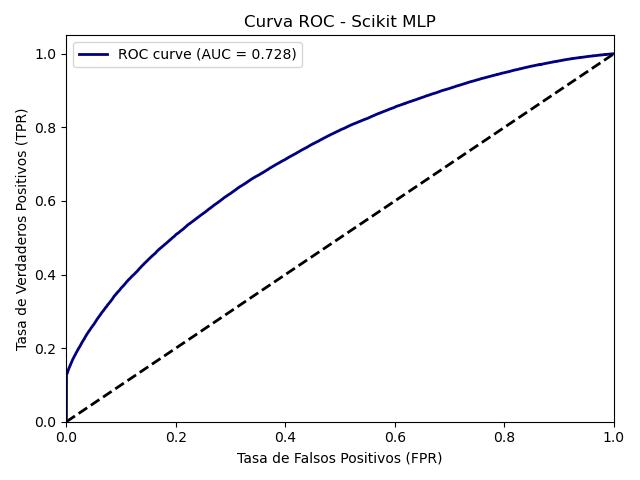

In [4]:
display(Image(filename="roc_curve_scikit.png"))

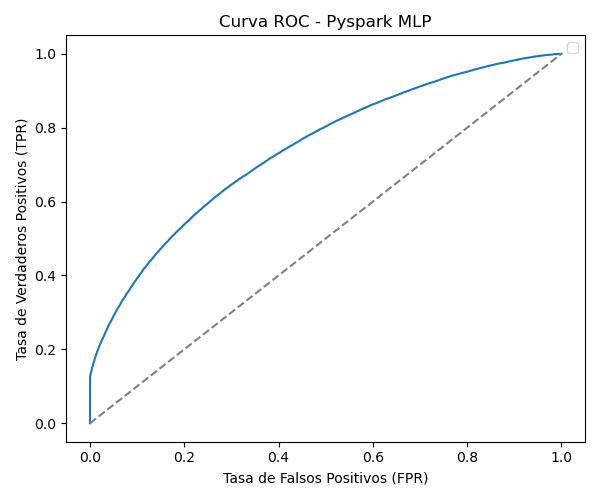

In [5]:
display(Image(filename="roc_curve_pyspark.png"))

## **Preguntas**

**1. ¿Qué entorno fue más rápido?**

En mi caso, **el modelo más rápido fue el ejecutado en Scikit-learn**, y de hecho la diferencia en tiempo fue bastante marcada. Esto puede deberse a distintos factores propios de cada librería. Sin embargo, un aspecto importante a resaltar es que, al trabajar con PySpark, la memoria RAM no alcanzaba a soportar toda la carga de datos, lo que ocasionó una ralentización en el proceso.

**2. ¿Cuál más preciso?**

El modelo más preciso fue el de PySpark. Este logró un mejor desempeño al identificar los casos correctos, mostrando mayor efectividad en la tarea propuesta.

**3. ¿Cuándo es útil PySpark?**

PySpark sirve cuando se trabaja con mucha información que una sola computadora no puede manejar bien. Permite repartir el trabajo y procesar los datos más rápido. En mi caso fue bastante difícil implementarlo, sim embargo noté que las métricas del modelo mejoraron, así que se podría decir que presenta ventajas cuando los datos son grandes.

**4. ¿Qué aporta LIME?**

LIME aporta un mayor entendimiento sobre cómo influyen las variables en cada instancia. Con esta técnica es posible visualizar qué tanta información aporta cada variable y, de esta manera, comprender por qué una instancia se clasifica como Default o no. En otras palabras, sirve como apoyo para interpretar y validar cómo funciona el modelo.